In [2]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
#dataset
DATA_PATH = Path("../data/raw/Dummy Data HSS.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(4572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [5]:
#colonnes
print(df.columns.tolist())

#infos
df.info()

display(df.head())

['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 178.7 KB


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [6]:
#rename columns
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())
df.head()

['tv', 'radio', 'social_media', 'influencer', 'sales']


,tv,radio,social_media,influencer,sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [7]:
#na values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percent": missing_percent
})

display(missing_df)

,missing_values,missing_percent
tv,10,0.22
radio,4,0.09
social_media,6,0.13
influencer,0,0.00
sales,6,0.13


In [8]:
#doublons

duplicates = df.duplicated().sum()

print("doublons :", duplicates)

if duplicates > 0:
    display(df[df.duplicated()])

doublons : 0


In [9]:
#stats
display(df.describe())

display(df.describe(include="object"))

,tv,radio,social_media,sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


C:\Users\dimit\AppData\Local\Temp\ipykernel_22268\2735351308.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,influencer
count,4572
unique,4
top,Mega
freq,1158


In [10]:
#dtypes

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numériques :", numeric_cols)
print("Variables catégorielles :", categorical_cols)

Variables numériques : ['tv', 'radio', 'social_media', 'sales']
Variables catégorielles : ['influencer']


C:\Users\dimit\AppData\Local\Temp\ipykernel_22268\2862913840.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


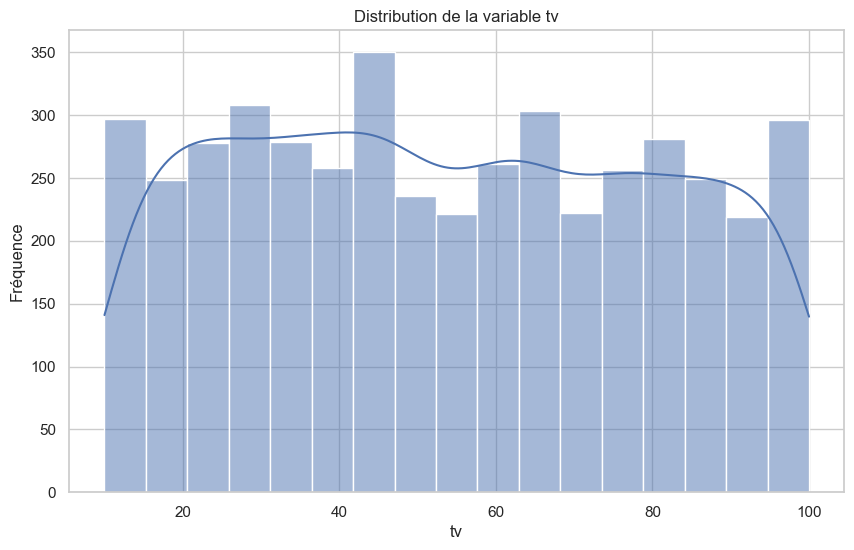

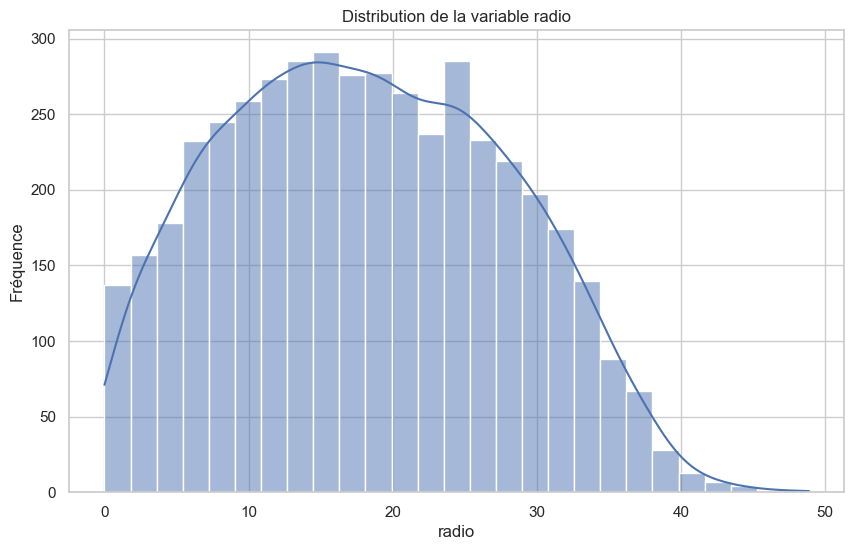

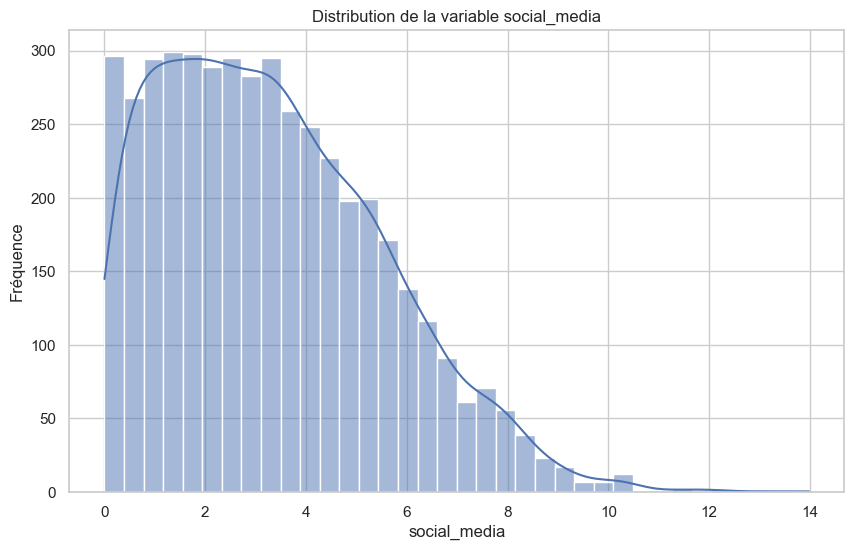

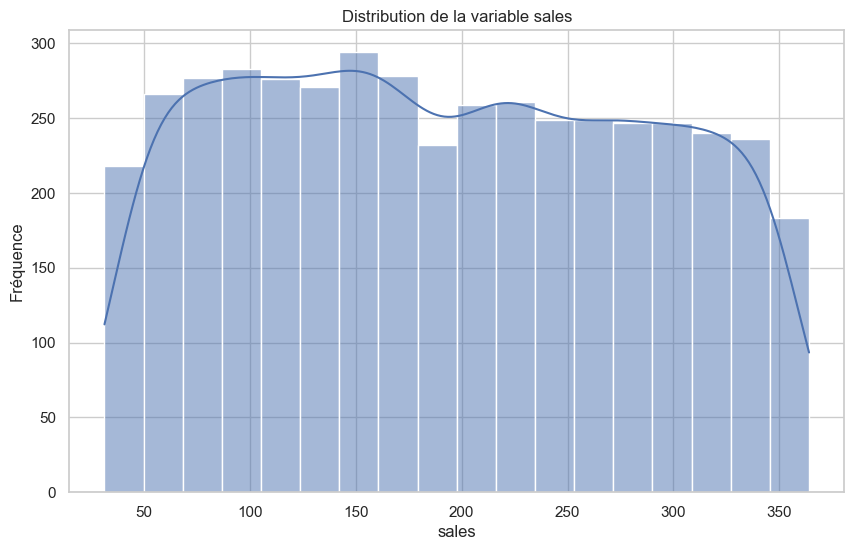

In [11]:
#distribution

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de la variable {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

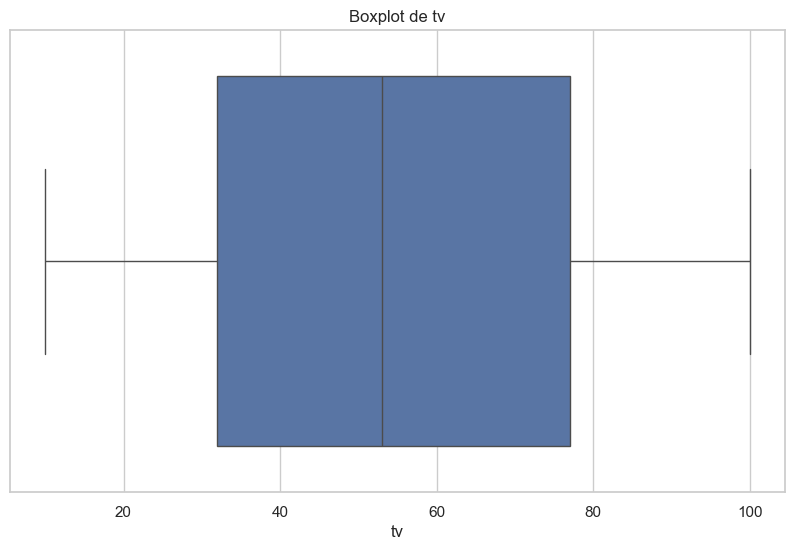

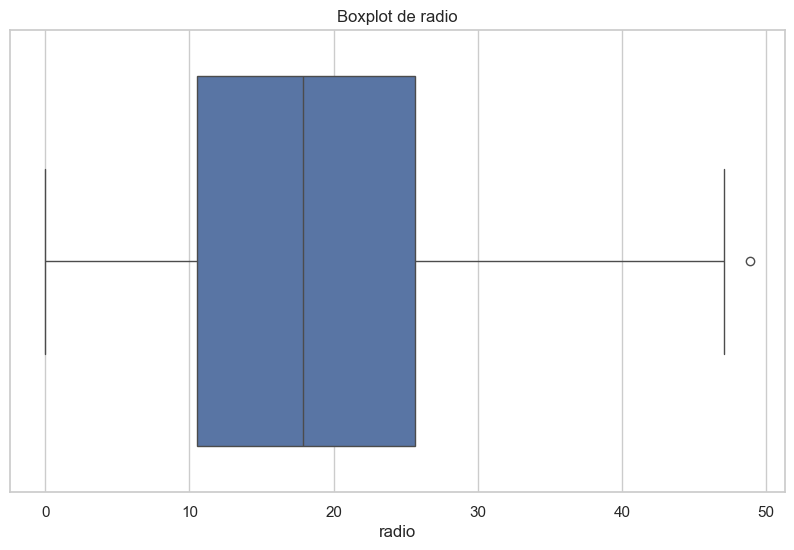

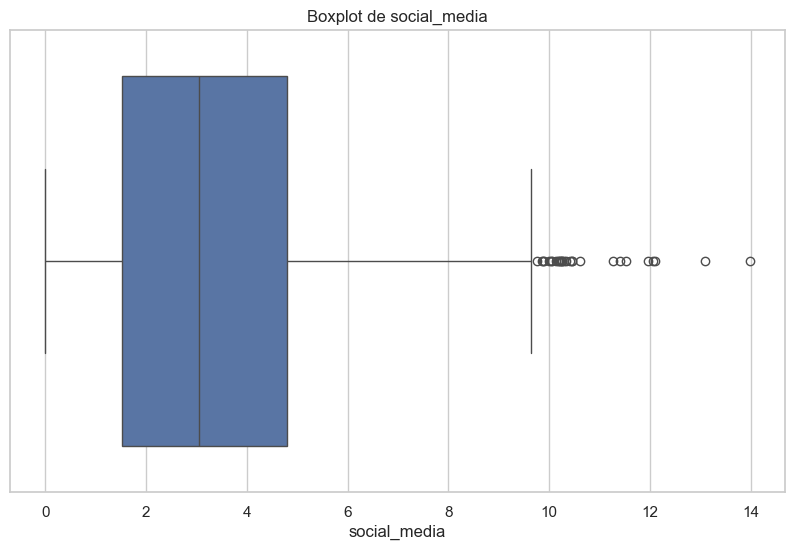

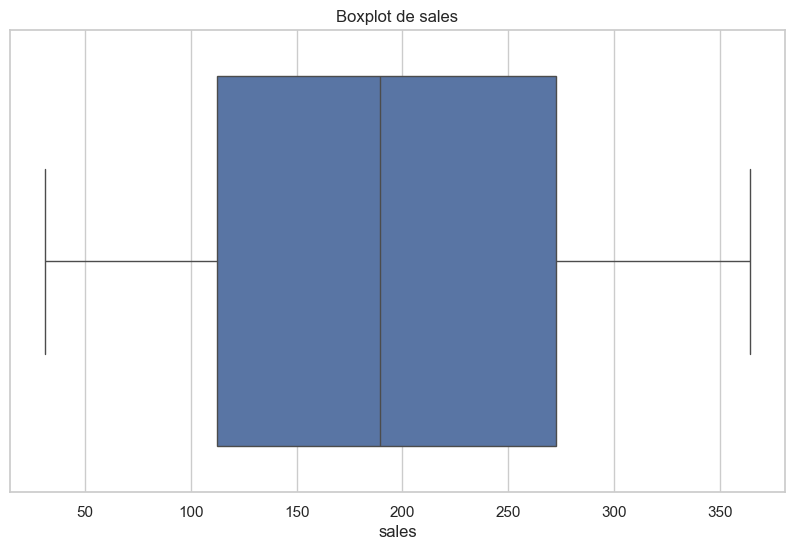

In [12]:
#extreme values

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

influencer
Mega     1158
Micro    1153
Nano     1139
Macro    1122
Name: count, dtype: int64


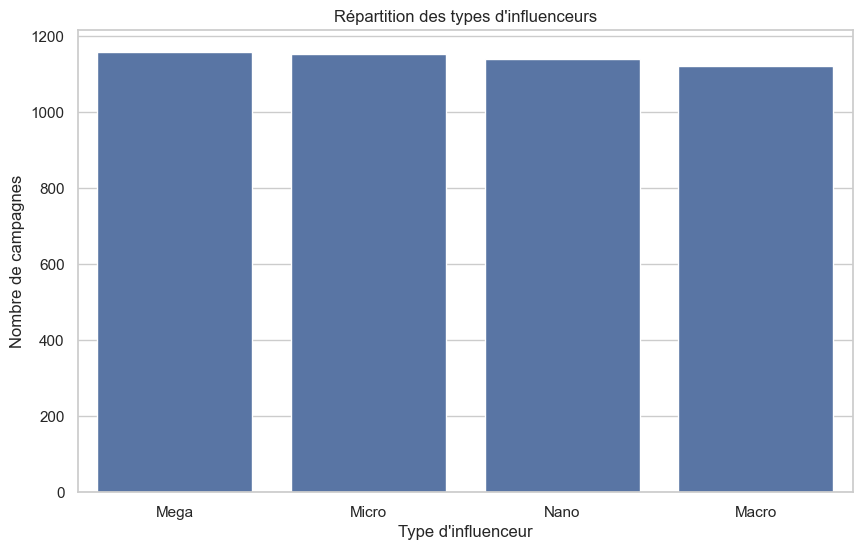

In [13]:
#influencer types

if "influencer" in df.columns:
    print(df["influencer"].value_counts())

    plt.figure()
    sns.countplot(data=df, x="influencer", order=df["influencer"].value_counts().index)
    plt.title("Répartition des types d'influenceurs")
    plt.xlabel("Type d'influenceur")
    plt.ylabel("Nombre de campagnes")
    plt.show()

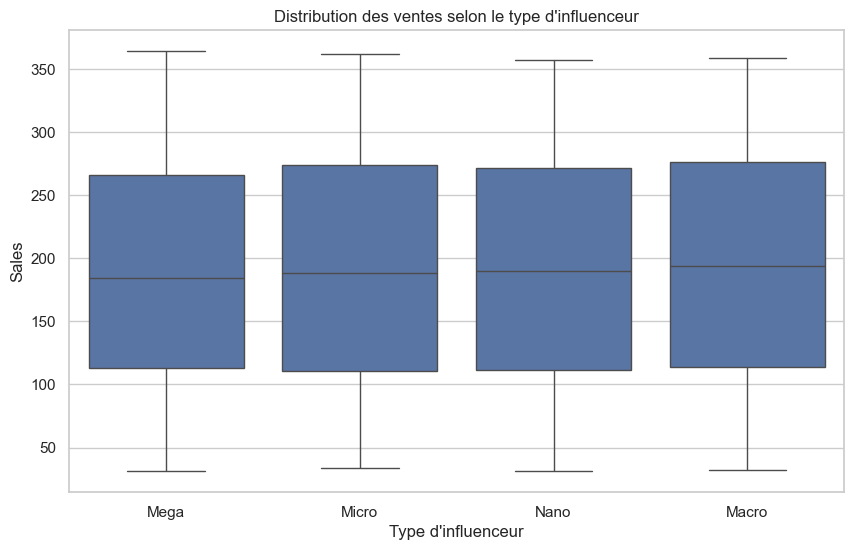

,mean,median,min,max,count
influencer,,,,,
Macro,195.613601,194.232285,32.566825,358.420739,1121
Nano,191.934304,189.655812,31.199409,357.124573,1137
Micro,191.809095,187.946693,33.719607,362.042123,1152
Mega,190.593666,184.167871,31.402262,364.079751,1156


In [14]:
#influencers and sales

if "influencer" in df.columns and "sales" in df.columns:
    plt.figure()
    sns.boxplot(data=df, x="influencer", y="sales")
    plt.title("Distribution des ventes selon le type d'influenceur")
    plt.xlabel("Type d'influenceur")
    plt.ylabel("Sales")
    plt.show()

    influencer_sales = df.groupby("influencer")["sales"].agg(["mean", "median", "min", "max", "count"])
    display(influencer_sales.sort_values(by="mean", ascending=False))

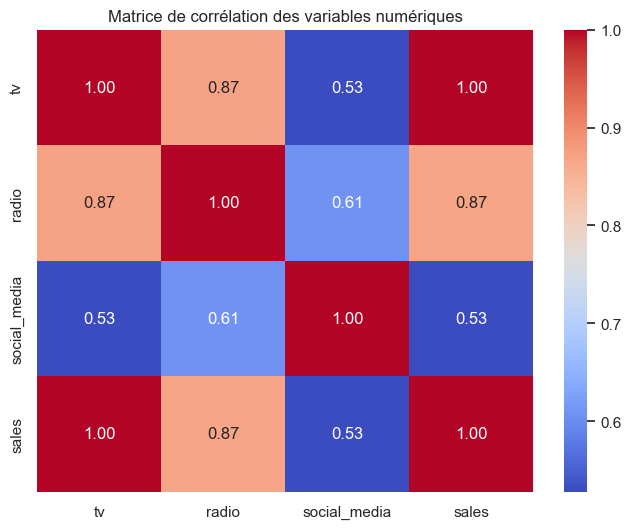

In [15]:
#corr matrix

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

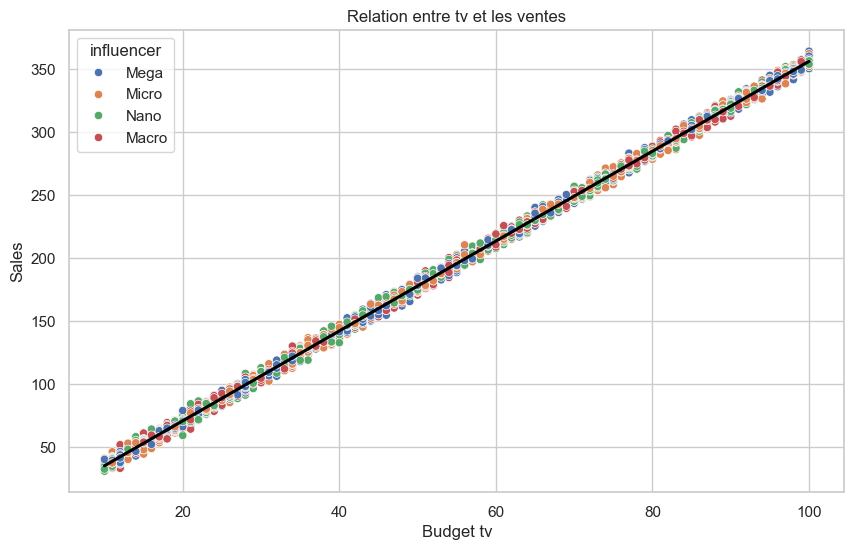

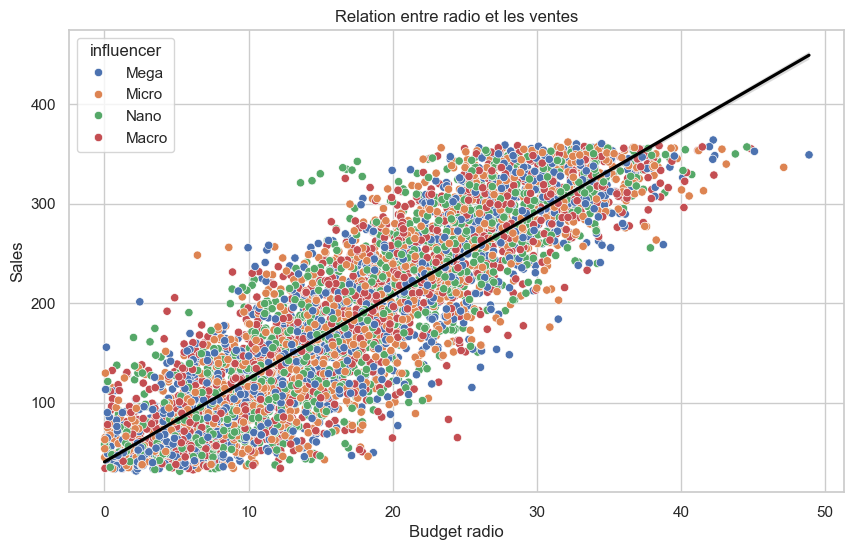

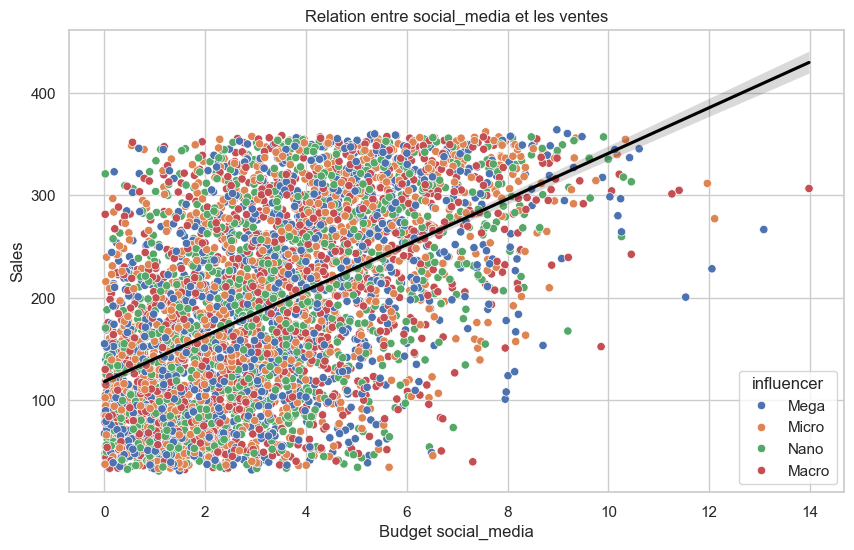

In [16]:
#marketing-ventes

budget_cols = [col for col in ["tv", "radio", "social_media"] if col in df.columns]

for col in budget_cols:
    plt.figure()
    sns.scatterplot(data=df, x=col, y="sales", hue="influencer" if "influencer" in df.columns else None)
    sns.regplot(data=df, x=col, y="sales", scatter=False, color="black")
    plt.title(f"Relation entre {col} et les ventes")
    plt.xlabel(f"Budget {col}")
    plt.ylabel("Sales")
    plt.show()

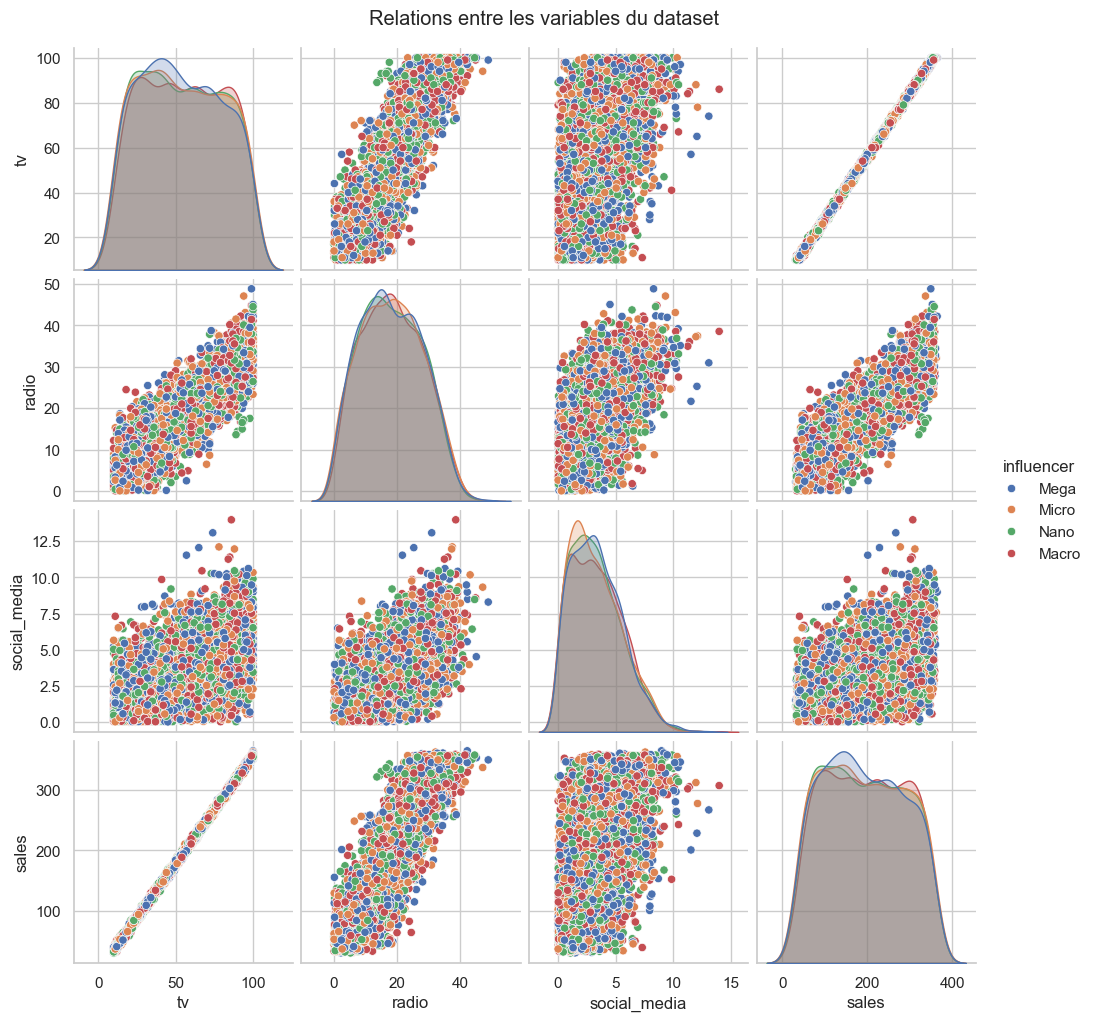

In [17]:


if "influencer" in df.columns:
    sns.pairplot(df, hue="influencer")
else:
    sns.pairplot(df)

plt.suptitle("Relations entre les variables du dataset", y=1.02)
plt.show()

In [18]:
#budget total et ROI

df["total_budget"] = df[budget_cols].sum(axis=1)

# ROI = ventes / budget total
# On évite la division par zéro
df["roi"] = np.where(df["total_budget"] > 0, df["sales"] / df["total_budget"], np.nan)

df[["tv", "radio", "social_media", "total_budget", "sales", "roi"]].head()

,tv,radio,social_media,total_budget,sales,roi
0,16.0,6.566231,2.907983,25.474214,54.732757,2.148555
1,13.0,9.237765,2.409567,24.647332,46.677897,1.893832
2,41.0,15.886446,2.913410,59.799856,150.177829,2.511341
3,83.0,30.020028,6.922304,119.942332,298.246340,2.486581
4,15.0,8.437408,1.405998,24.843406,56.594181,2.278036


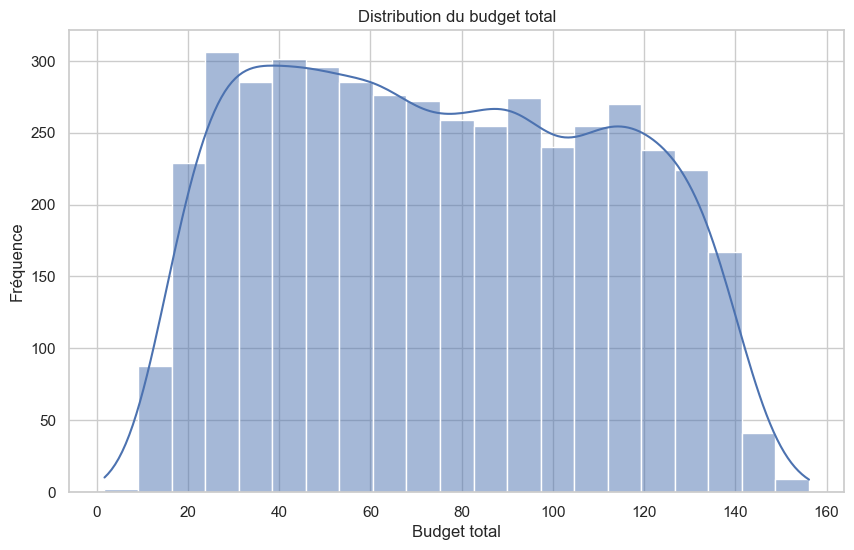

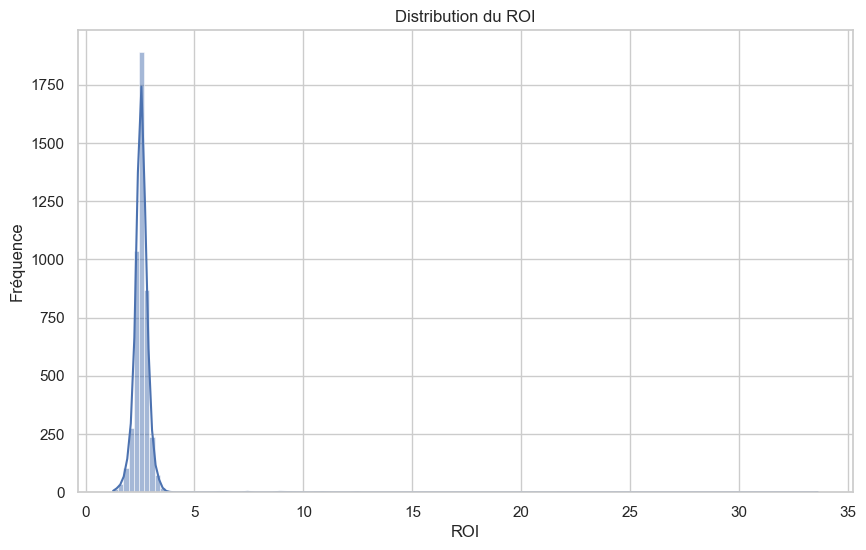

In [19]:
#analyse

plt.figure()
sns.histplot(df["total_budget"], kde=True)
plt.title("Distribution du budget total")
plt.xlabel("Budget total")
plt.ylabel("Fréquence")
plt.show()

plt.figure()
sns.histplot(df["roi"], kde=True)
plt.title("Distribution du ROI")
plt.xlabel("ROI")
plt.ylabel("Fréquence")
plt.show()

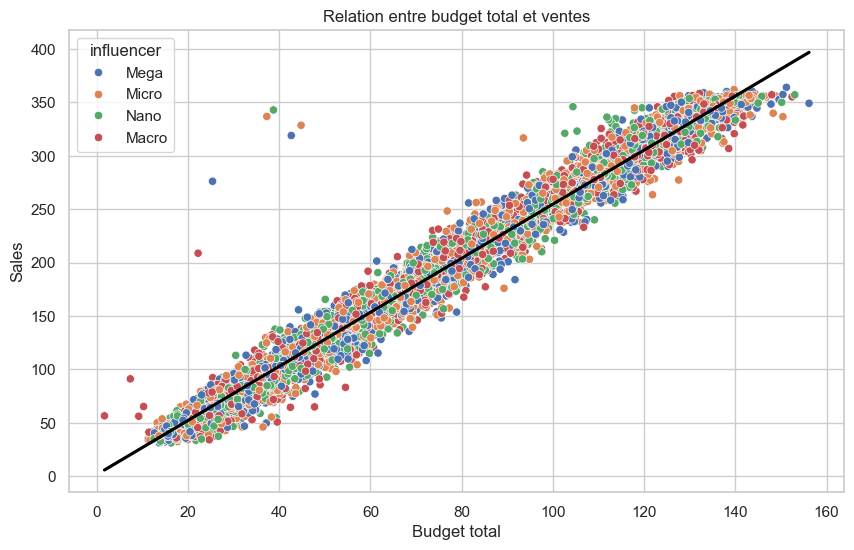

In [20]:
# Relation budget total / ventes

plt.figure()
sns.scatterplot(data=df, x="total_budget", y="sales", hue="influencer" if "influencer" in df.columns else None)
sns.regplot(data=df, x="total_budget", y="sales", scatter=False, color="black")
plt.title("Relation entre budget total et ventes")
plt.xlabel("Budget total")
plt.ylabel("Sales")
plt.show()

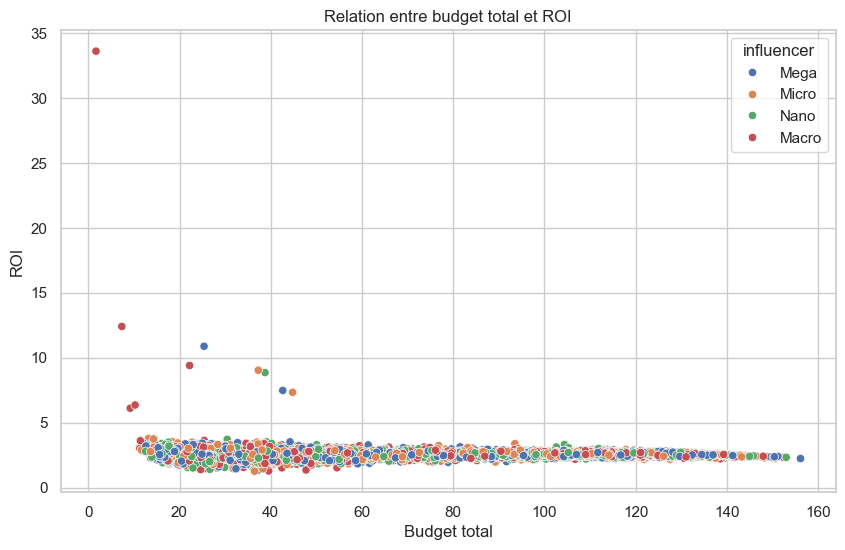

In [21]:
# Relation budget total / ROI

plt.figure()
sns.scatterplot(data=df, x="total_budget", y="roi", hue="influencer" if "influencer" in df.columns else None)
plt.title("Relation entre budget total et ROI")
plt.xlabel("Budget total")
plt.ylabel("ROI")
plt.show()

,mean,median,min,max,count
influencer,,,,,
Macro,2.600414,2.560016,1.282401,33.593142,1121
Micro,2.559004,2.554018,1.265415,9.035465,1152
Nano,2.556139,2.541326,1.388173,8.852616,1137
Mega,2.554680,2.552763,1.339874,10.879727,1156


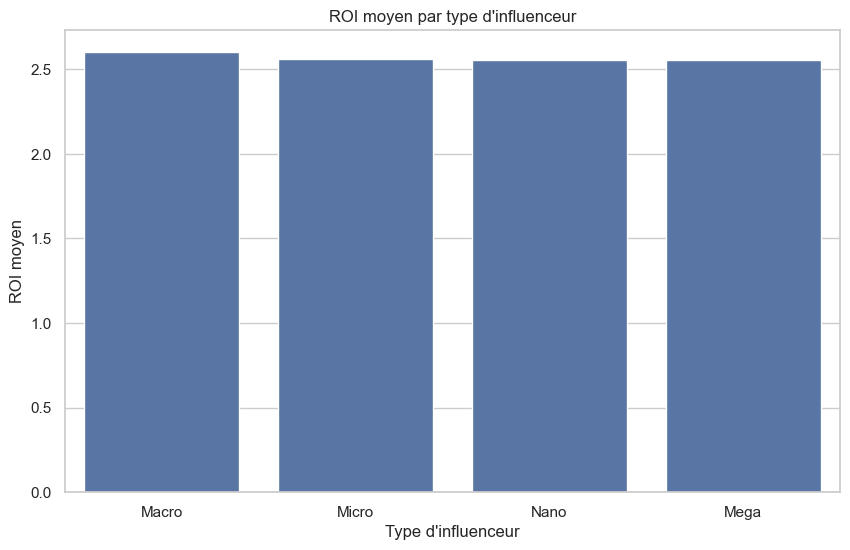

In [22]:
#roi par influencer

if "influencer" in df.columns:
    roi_by_influencer = df.groupby("influencer")["roi"].agg(["mean", "median", "min", "max", "count"])
    display(roi_by_influencer.sort_values(by="mean", ascending=False))

    plt.figure()
    sns.barplot(
        data=df,
        x="influencer",
        y="roi",
        estimator="mean",
        errorbar=None,
        order=df.groupby("influencer")["roi"].mean().sort_values(ascending=False).index
    )
    plt.title("ROI moyen par type d'influenceur")
    plt.xlabel("Type d'influenceur")
    plt.ylabel("ROI moyen")
    plt.show()

In [23]:
# ==============================
# 19. PART DE CHAQUE CANAL DANS LE BUDGET TOTAL
# ==============================

for col in budget_cols:
    df[f"{col}_share"] = df[col] / df["total_budget"]

share_cols = [f"{col}_share" for col in budget_cols]

display(df[share_cols].head())

,tv_share,radio_share,social_media_share
0,0.628086,0.257760,0.114154
1,0.527440,0.374798,0.097762
2,0.685620,0.265660,0.048719
3,0.691999,0.250287,0.057714
4,0.603782,0.339624,0.056594


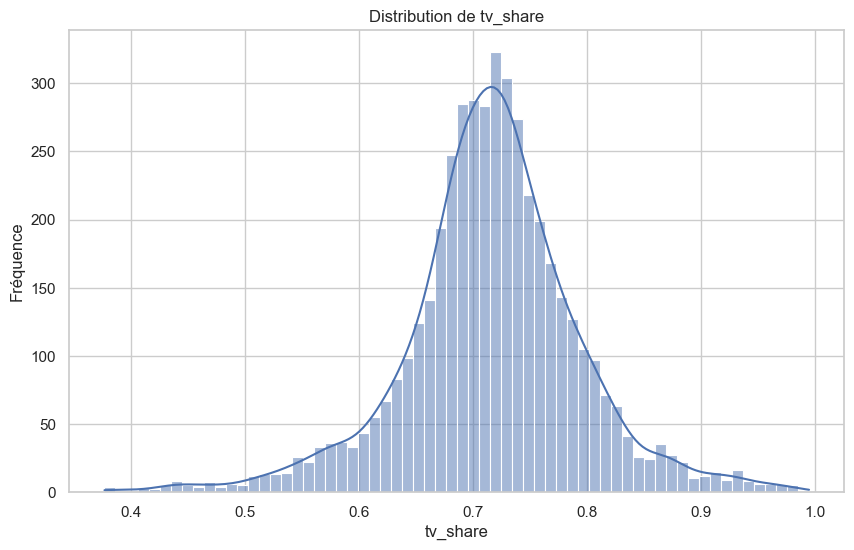

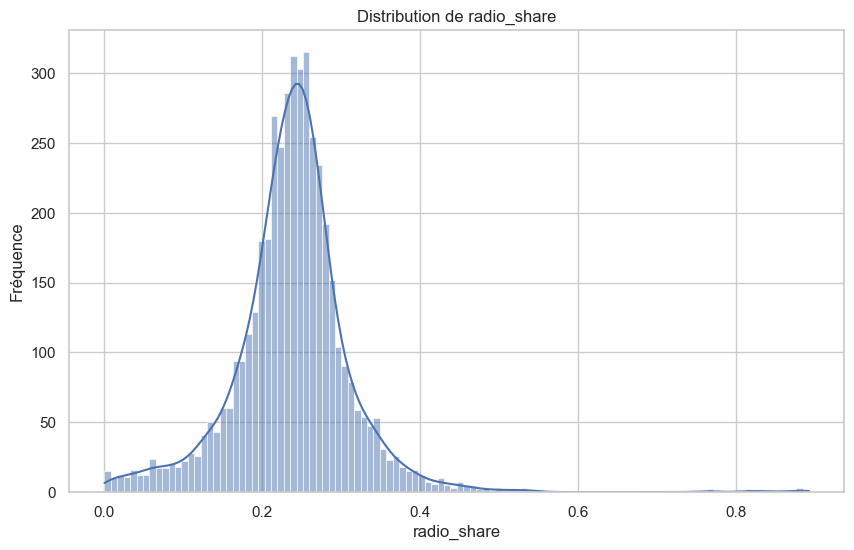

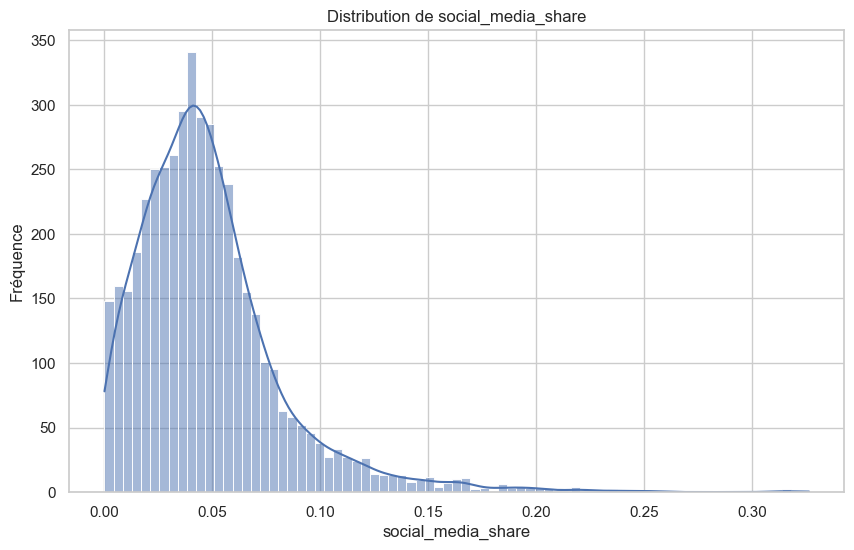

In [24]:
# Distribution des parts budgétaires

for col in share_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [25]:
#outliers

def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound


for col in numeric_cols + ["total_budget", "roi"]:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\nVariable : {col}")
    print(f"Bornes : [{lower:.2f}, {upper:.2f}]")
    print(f"Nombre d'outliers : {len(outliers)}")


Variable : tv
Bornes : [-35.50, 144.50]
Nombre d'outliers : 0

Variable : radio
Bornes : [-12.16, 48.34]
Nombre d'outliers : 1

Variable : social_media
Bornes : [-3.39, 9.73]
Nombre d'outliers : 28

Variable : sales
Bornes : [-127.95, 512.79]
Nombre d'outliers : 0

Variable : total_budget
Bornes : [-49.54, 200.37]
Nombre d'outliers : 0

Variable : roi
Bornes : [1.97, 3.14]
Nombre d'outliers : 265


In [26]:
#top des roi

top_roi = df.sort_values(by="roi", ascending=False).head(10)

display(top_roi)

,tv,radio,social_media,influencer,sales,total_budget,roi,tv_share,radio_share,social_media_share
183,NaN,1.287060,0.396179,Macro,56.545293,1.683239,33.593142,NaN,0.764633,0.235367
75,NaN,6.482293,0.866845,Macro,91.177216,7.349138,12.406518,NaN,0.882048,0.117952
13,NaN,22.351667,3.031815,Mega,276.165351,25.383482,10.879727,NaN,0.880560,0.119440
210,NaN,17.007075,5.199635,Macro,208.816382,22.206709,9.403301,NaN,0.765853,0.234147
119,NaN,30.470485,6.806919,Micro,336.818690,37.277404,9.035465,NaN,0.817398,0.182602
26,NaN,34.111674,4.624148,Nano,342.913372,38.735822,8.852616,NaN,0.880623,0.119377
46,NaN,34.859637,7.781417,Mega,318.969784,42.641054,7.480345,NaN,0.817513,0.182487
163,NaN,38.118424,6.676611,Micro,328.555184,44.795035,7.334634,NaN,0.850952,0.149048
141,NaN,9.164464,1.096681,Macro,65.259189,10.261145,6.359835,NaN,0.893123,0.106877
99,NaN,7.635819,1.554146,Macro,56.186730,9.189965,6.113922,NaN,0.830887,0.169113


In [27]:
#top 10 ventes
top_sales = df.sort_values(by="sales", ascending=False).head(10)

display(top_sales)

,tv,radio,social_media,influencer,sales,total_budget,roi,tv_share,radio_share,social_media_share
1925,100.0,42.225232,8.977117,Mega,364.079751,151.202349,2.407897,0.661365,0.279263,0.059372
2823,100.0,32.148208,7.565100,Micro,362.042123,139.713307,2.591322,0.715751,0.230101,0.054147
2412,100.0,34.488205,9.187200,Mega,360.400053,143.675404,2.508432,0.696013,0.240043,0.063944
3338,100.0,32.735142,5.361312,Mega,360.109683,138.096454,2.607668,0.724132,0.237045,0.038823
2314,100.0,27.779895,5.280721,Mega,359.038843,133.060616,2.698310,0.751537,0.208776,0.039687
1408,100.0,34.369133,5.773973,Mega,358.897563,140.143105,2.560936,0.713556,0.245243,0.041201
2378,100.0,28.656719,3.518440,Macro,358.420739,132.175158,2.711710,0.756572,0.216809,0.026620
453,100.0,38.470629,5.793620,Macro,358.350539,144.264249,2.483987,0.693172,0.266668,0.040160
3633,100.0,30.107064,8.054540,Mega,357.788195,138.161604,2.589636,0.723790,0.217912,0.058298
2442,100.0,31.420838,2.924103,Micro,357.587130,134.344941,2.661709,0.744353,0.233882,0.021766


sales_category
Low Performance       1522
Medium Performance    1522
High Performance      1522
Name: count, dtype: int64


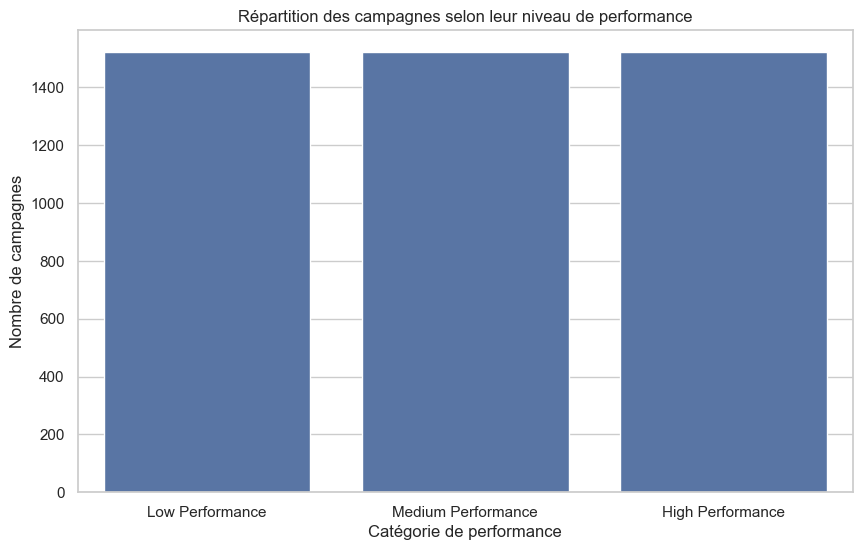

In [28]:
#ANALYSE DES CAMPAGNES FAIBLES / MOYENNES / FORTES

df["sales_category"] = pd.qcut(
    df["sales"],
    q=3,
    labels=["Low Performance", "Medium Performance", "High Performance"]
)

print(df["sales_category"].value_counts())

plt.figure()
sns.countplot(data=df, x="sales_category")
plt.title("Répartition des campagnes selon leur niveau de performance")
plt.xlabel("Catégorie de performance")
plt.ylabel("Nombre de campagnes")
plt.show()

In [29]:
# Budget moyen par catégorie de performance

performance_budget = df.groupby("sales_category")[budget_cols + ["total_budget", "roi"]].mean()

display(performance_budget)

,tv,radio,social_media,total_budget,roi
sales_category,,,,,
Low Performance,24.354414,8.703841,2.043905,35.024031,2.528854
Medium Performance,53.280736,17.645191,3.176994,74.065827,2.580687
High Performance,84.590639,28.136500,4.755692,117.158591,2.592548


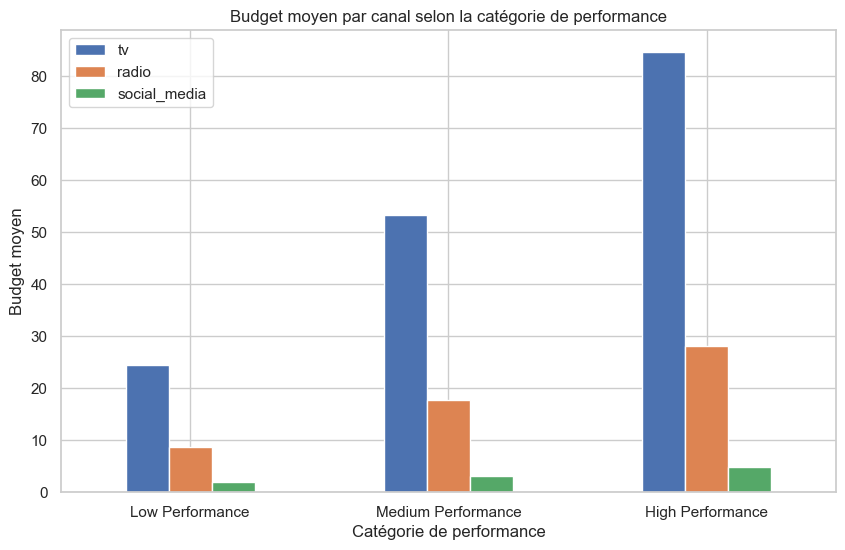

In [30]:
# Visualisation du budget moyen selon la performance

performance_budget[budget_cols].plot(kind="bar", figsize=(10, 6))
plt.title("Budget moyen par canal selon la catégorie de performance")
plt.xlabel("Catégorie de performance")
plt.ylabel("Budget moyen")
plt.xticks(rotation=0)
plt.show()

sales                 1.000000
tv                    0.999497
total_budget          0.983138
radio                 0.869105
social_media          0.528906
tv_share              0.127614
roi                   0.053341
radio_share           0.003830
social_media_share   -0.293376
Name: sales, dtype: float64

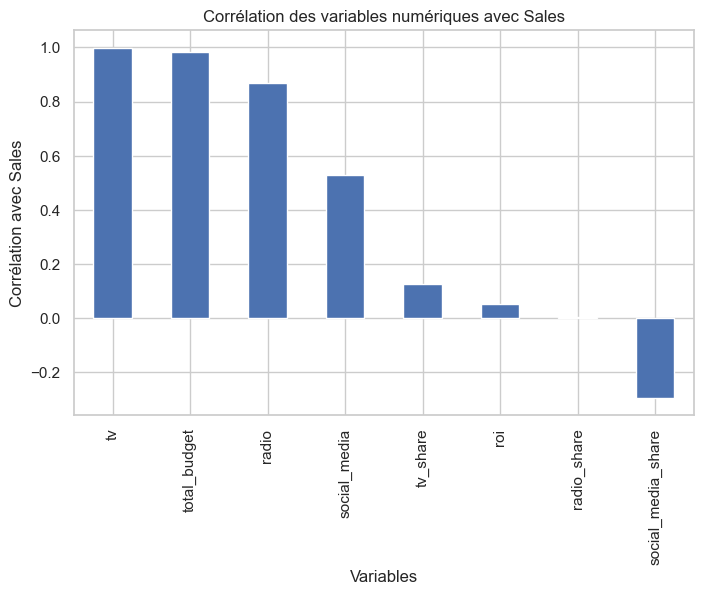

In [31]:
#SYNTHÈSE AUTOMATIQUE DES CORRÉLATIONS AVEC SALES

if "sales" in df.columns:
    sales_corr = df.corr(numeric_only=True)["sales"].sort_values(ascending=False)
    display(sales_corr)

    plt.figure(figsize=(8, 5))
    sales_corr.drop("sales").plot(kind="bar")
    plt.title("Corrélation des variables numériques avec Sales")
    plt.xlabel("Variables")
    plt.ylabel("Corrélation avec Sales")
    plt.show()

In [ ]:
OUTPUT_PATH = Path("../data/processed/marketing_and_sales_eda_enriched.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset enrichi sauvegardé ici : {OUTPUT_PATH}")